# 6CS012 Final Portfolio Project 2026
## Part II – Vision Tasks: Image Classification with CNN
**Dataset:** Animals-10 (Kaggle – alessiocorrado99/animals10)  
**Student Name:** *Kamana Ramtel*  
**Student ID:** *200408*  

---
### Notebook Structure
- **Section 0** – Environment Setup & Dataset Preparation
- **Section 1** – Data Understanding, Analysis & Visualization
- **Section 2** – Baseline CNN Model 
- **Section 3** – Deeper CNN with Regularization 
- **Section 4** – Experimentation & Comparative Analysis 
- **Section 5** – Transfer Learning / Fine-Tuning MobileNetV2 

---
## Section 0 – Environment Setup & Dataset Preparation

### Dataset Description
The **Animals-10** dataset contains ~26,000 images across **10 animal classes**:
butterfly, cat, chicken, cow, dog, elephant, horse, sheep, spider, squirrel.
Originally sourced from Google Images with Italian folder names, translated to English below.




In [14]:
# Verify GPU is available — run this FIRST before any training
import tensorflow as tf
print("TensorFlow version :", tf.__version__)
print("GPU available      :", tf.config.list_physical_devices('GPU'))
print("CPU                :", tf.config.list_physical_devices('CPU'))


TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
CPU                : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [15]:
# Core Imports
import numpy as np
import matplotlib.pyplot as plt
import os, time, random, shutil, math, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

print("All libraries imported successfully.")


All libraries imported successfully.


In [16]:
# Configuration & Dataset Reduction
RAW_DIR   = '/kaggle/input/datasets/alessiocorrado99/animals10/raw-img'   # Kaggle input (read-only)   # Kaggle input (read-only)
WORK_DIR  = '/kaggle/working/animals10_30pct'    # our working copy

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
SEED       = 30
EPOCHS     = 50   # EarlyStopping will stop early automatically

SAMPLE_RATIO = 0.30
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15

TRANSLATE = {
    'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant',
    'farfalla': 'butterfly', 'gallina': 'chicken', 'gatto': 'cat',
    'mucca': 'cow', 'pecora': 'sheep', 'ragno': 'spider', 'scoiattolo': 'squirrel'
}
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

random.seed(SEED)

if os.path.isdir(WORK_DIR):
    print("Reduced dataset already exists — skipping copy.")
else:
    print("Building 30% stratified dataset ...")
    total_copied = 0
    for folder in sorted(os.listdir(RAW_DIR)):
        src_dir = os.path.join(RAW_DIR, folder)
        if not os.path.isdir(src_dir):
            continue
        cls_name  = TRANSLATE.get(folder.strip().lower(), folder)
        all_files = [f for f in os.listdir(src_dir)
                     if os.path.splitext(f)[1].lower() in IMG_EXTS]
        random.shuffle(all_files)
        n_keep  = math.floor(len(all_files) * SAMPLE_RATIO)
        kept    = all_files[:n_keep]
        n_train = math.floor(n_keep * TRAIN_RATIO)
        n_val   = math.floor(n_keep * VAL_RATIO)
        n_test  = n_keep - n_train - n_val
        for split_name, files in [
            ('train', kept[:n_train]),
            ('val',   kept[n_train:n_train+n_val]),
            ('test',  kept[n_train+n_val:])
        ]:
            dst = os.path.join(WORK_DIR, split_name, cls_name)
            os.makedirs(dst, exist_ok=True)
            for fname in files:
                shutil.copy2(os.path.join(src_dir, fname), os.path.join(dst, fname))
            total_copied += len(files)
        print("  {:12s}  kept={:4d}  train={}  val={}  test={}".format(
            cls_name, n_keep, n_train, n_val, n_test))
    print("\nDone! {:,} files copied.".format(total_copied))

TRAIN_DIR = os.path.join(WORK_DIR, 'train')
VAL_DIR   = os.path.join(WORK_DIR, 'val')
TEST_DIR  = os.path.join(WORK_DIR, 'test')
DATA_DIR  = TRAIN_DIR

print("\nTRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)
print("TEST_DIR  :", TEST_DIR)


Reduced dataset already exists — skipping copy.

TRAIN_DIR : /kaggle/working/animals10_30pct/train
VAL_DIR   : /kaggle/working/animals10_30pct/val
TEST_DIR  : /kaggle/working/animals10_30pct/test


---
## Section 1 – Data Understanding, Analysis & Visualization (Part A – 2.5.1)


In [17]:
# Dataset class counts
class_counts = {}
for folder in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, folder)
    if os.path.isdir(path):
        class_counts[folder] = len(os.listdir(path))

print("Number of classes  :", len(class_counts))
print("Total train images : {:,}".format(sum(class_counts.values())))
print("Total val images   : {:,}".format(
    sum(len(os.listdir(os.path.join(VAL_DIR, c)))
        for c in os.listdir(VAL_DIR)
        if os.path.isdir(os.path.join(VAL_DIR, c)))))
print("Total test images  : {:,}\n".format(
    sum(len(os.listdir(os.path.join(TEST_DIR, c)))
        for c in os.listdir(TEST_DIR)
        if os.path.isdir(os.path.join(TEST_DIR, c)))))
for cls in sorted(class_counts):
    print("  {:<12} {}".format(cls, class_counts[cls]))


Number of classes  : 10
Total train images : 5,491
Total val images   : 1,170
Total test images  : 1,187

  butterfly    443
  cat          350
  chicken      650
  cow          391
  dog          1020
  elephant     303
  horse        550
  sheep        382
  spider       1012
  squirrel     390


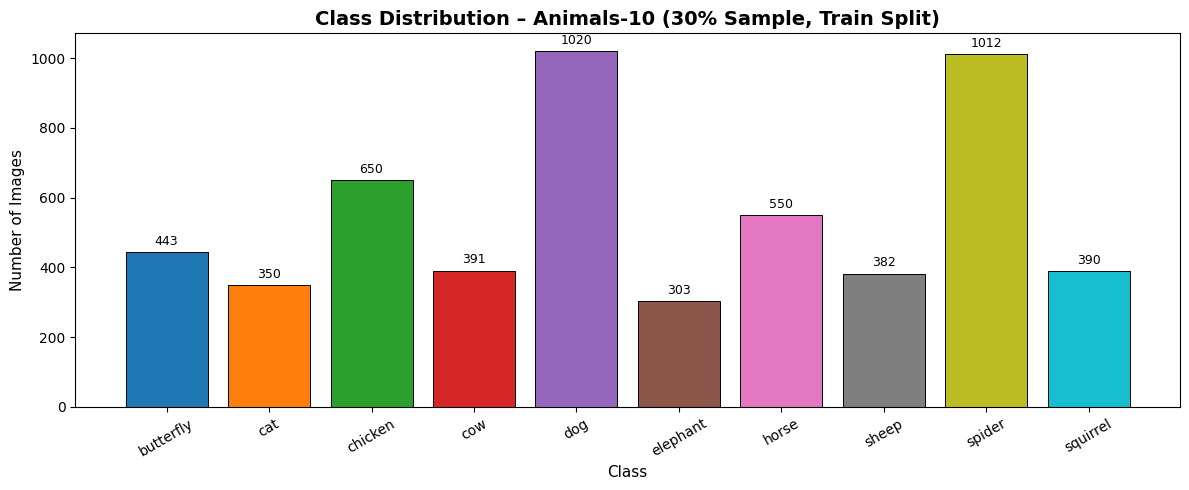

Saved: class_distribution.png


In [18]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=plt.cm.tab10.colors, edgecolor='black', linewidth=0.7)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Class Distribution – Animals-10 (30% Sample, Train Split)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Number of Images', fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Saved: class_distribution.png")


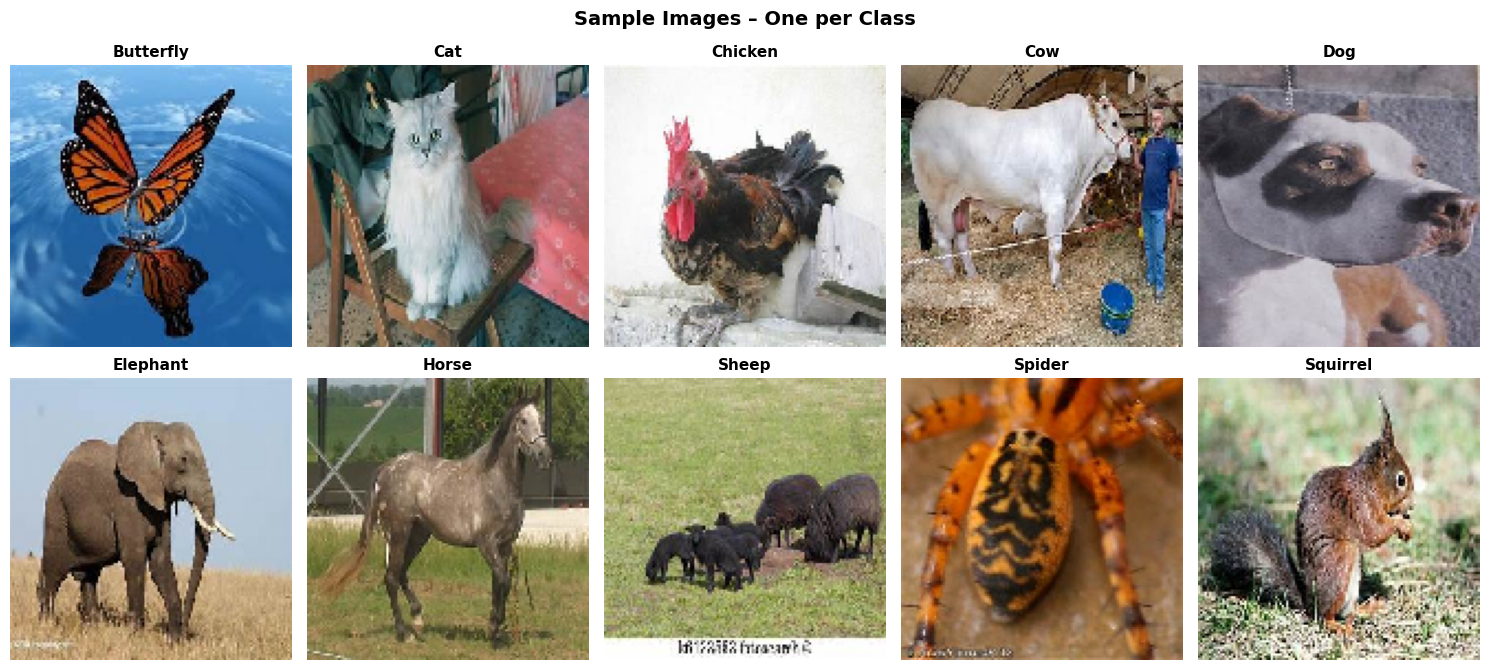

Saved: sample_images.png


In [19]:
# Sample images — one per class
CLASS_NAMES_VIS = sorted([
    d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))
])
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()
for idx, cls in enumerate(CLASS_NAMES_VIS):
    cls_path = os.path.join(DATA_DIR, cls)
    img = load_img(os.path.join(cls_path, random.choice(os.listdir(cls_path))),
                   target_size=IMG_SIZE)
    axes[idx].imshow(img)
    axes[idx].set_title(cls.capitalize(), fontsize=11, fontweight='bold')
    axes[idx].axis('off')
plt.suptitle('Sample Images – One per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()
print("Saved: sample_images.png")


In [20]:
# Data Generators
# Preprocessing: rescale pixels to [0,1], resize to 128x128
# Augmentation on train only: rotation, flip, zoom, shift, shear
# No augmentation on val/test — ensures unbiased evaluation

train_datagen = ImageDataGenerator(
    rescale=1.0/255, rotation_range=20, width_shift_range=0.15,
    height_shift_range=0.15, shear_range=0.10, zoom_range=0.15,
    horizontal_flip=True, fill_mode='nearest'
)
eval_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=True
)
val_gen = eval_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=False
)
test_gen = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=False
)

CLASS_NAMES = [k for k, v in sorted(train_gen.class_indices.items(), key=lambda x: x[1])]
NUM_CLASSES  = len(CLASS_NAMES)

print("Training   batches : {:>3}  ({:,} images)".format(len(train_gen), train_gen.samples))
print("Validation batches : {:>3}  ({:,} images)".format(len(val_gen),   val_gen.samples))
print("Test       batches : {:>3}  ({:,} images)".format(len(test_gen),  test_gen.samples))
print("Classes ({}) : {}".format(NUM_CLASSES, CLASS_NAMES))


Found 5491 images belonging to 10 classes.
Found 1170 images belonging to 10 classes.
Found 1187 images belonging to 10 classes.
Training   batches : 172  (5,491 images)
Validation batches :  37  (1,170 images)
Test       batches :  38  (1,187 images)
Classes (10) : ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


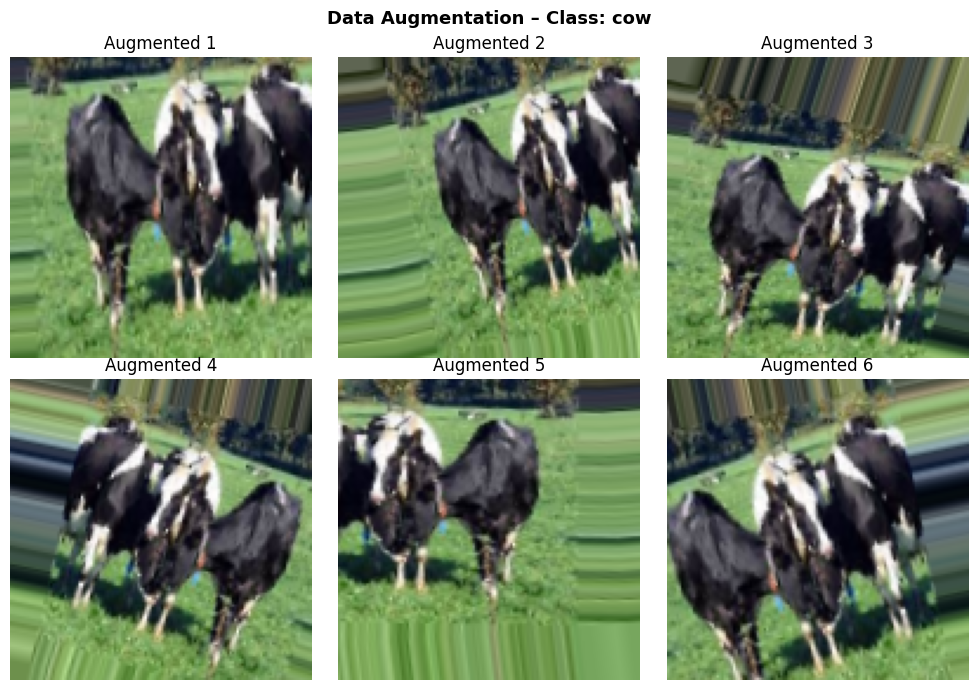

Saved: augmentation_examples.png


In [21]:
# Augmentation visualisation — shows effect of augmentation on one image
X_sample, y_sample = next(train_gen)
fixed_img   = X_sample[0]
fixed_label = np.argmax(y_sample[0])

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()
for i in range(6):
    aug = train_gen.image_data_generator.random_transform(fixed_img)
    axes[i].imshow(aug)
    axes[i].set_title("Augmented {}".format(i+1))
    axes[i].axis('off')
plt.suptitle("Data Augmentation – Class: {}".format(CLASS_NAMES[fixed_label]),
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150)
plt.show()
print("Saved: augmentation_examples.png")


---
## Section 2 – Baseline CNN Model (Part A – 2.5.2)


In [22]:
# Helper: plot training curves
def plot_history(history, title='Model', color='steelblue'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['loss'],     label='Train Loss', color=color, linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss',   color=color, linestyle='--', linewidth=2)
    ax1.set_title(title + ' Loss Curve', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['accuracy'],     label='Train Acc', color='tomato', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Val Acc',   color='tomato', linestyle='--', linewidth=2)
    ax2.set_title(title + ' Accuracy Curve', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = title.replace(' ', '_').replace('/', '_') + '_curves.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print("Saved:", fname)


In [23]:
# Baseline CNN Architecture
INPUT_SHAPE = IMG_SIZE + (3,)

def build_baseline_model(input_shape, num_classes):
    model = models.Sequential(name='Baseline_CNN')
    # Block 1: 32 filters, 3x3 kernel, ReLU
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2,2)))
    # Block 2: 64 filters
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    # Block 3: 128 filters
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    # Fully Connected (3 layers)
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64,  activation='relu'))
    # Output
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

baseline_model = build_baseline_model(INPUT_SHAPE, NUM_CLASSES)
baseline_model.summary()


I0000 00:00:1778334295.329383      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778334295.335208      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,914 (32.52 MB)

 Trainable params: 8,523,914 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Compile & Train Baseline
baseline_model.compile(optimizer='adam',
                        loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_base = EarlyStopping(monitor='val_loss', patience=5,
                                 restore_best_weights=True, verbose=1)
reduce_lr_base  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                     patience=3, min_lr=1e-6, verbose=1)

print("Training Baseline CNN ...")
start_time = time.time()
baseline_history = baseline_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=[early_stop_base, reduce_lr_base], verbose=1
)
baseline_train_time = time.time() - start_time
print("\nBaseline training time: {:.1f} seconds".format(baseline_train_time))


Training Baseline CNN ...
Epoch 1/50


I0000 00:00:1778334298.919641     165 service.cc:152] XLA service 0x7afdfc00e120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778334298.919690     165 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778334298.919698     165 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778334299.367595     165 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/172 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - accuracy: 0.0920 - loss: 2.4048

I0000 00:00:1778334302.866243     165 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 173ms/step - accuracy: 0.2076 - loss: 2.1987 - val_accuracy: 0.3419 - val_loss: 1.8929 - learning_rate: 0.0010
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.3130 - loss: 1.9035 - val_accuracy: 0.3179 - val_loss: 1.9358 - learning_rate: 0.0010
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - accuracy: 0.3752 - loss: 1.7241 - val_accuracy: 0.4111 - val_loss: 1.7028 - learning_rate: 0.0010
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - accuracy: 0.4371 - loss: 1.5992 - val_accuracy: 0.4513 - val_loss: 1.6134 - learning_rate: 0.0010
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - accuracy: 0.4729 - loss: 1.5021 - val_accuracy: 0.4530 - val_loss: 1.6373 - learning_rate: 0.0010
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 146ms/step - accuracy: 0.4899 - loss: 1.4386 - val_accuracy: 0.4744 - val_loss: 1.4698 - learning_rate: 0.0010
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 26s 149ms/step - accuracy: 0.5196 - loss:

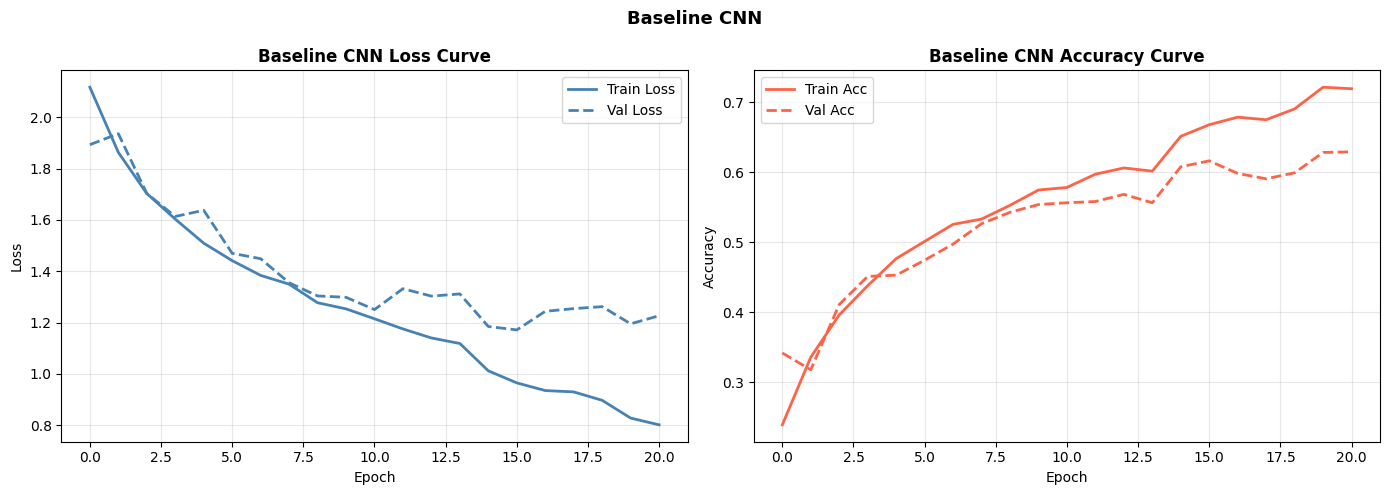

Saved: Baseline_CNN_curves.png


In [25]:
plot_history(baseline_history, title='Baseline CNN', color='steelblue')

In [26]:
# Evaluate Baseline
val_gen.reset()
base_loss, base_acc = baseline_model.evaluate(val_gen, verbose=0)
print("Baseline – Val Loss    : {:.4f}".format(base_loss))
print("Baseline – Val Accuracy: {:.4f} ({:.2f}%)".format(base_acc, base_acc*100))


Baseline – Val Loss    : 1.1713
Baseline – Val Accuracy: 0.6162 (61.62%)


In [27]:
# Classification Report – Baseline
val_gen.reset()
y_true, y_pred_probs = [], []
for i in range(len(val_gen)):
    X_b, y_b = val_gen[i]
    y_pred_probs.extend(baseline_model.predict(X_b, verbose=0))
    y_true.extend(np.argmax(y_b, axis=1))
y_pred = np.argmax(y_pred_probs, axis=1)
print("Classification Report – Baseline CNN")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Classification Report – Baseline CNN
              precision    recall  f1-score   support

   butterfly       0.66      0.86      0.75        94
         cat       0.59      0.25      0.36        75
     chicken       0.72      0.76      0.74       139
         cow       0.43      0.55      0.49        83
         dog       0.70      0.56      0.62       218
    elephant       0.34      0.70      0.46        64
       horse       0.55      0.52      0.54       117
       sheep       0.53      0.53      0.53        81
      spider       0.78      0.76      0.77       216
    squirrel       0.62      0.42      0.50        83

    accuracy                           0.62      1170
   macro avg       0.59      0.59      0.57      1170
weighted avg       0.64      0.62      0.61      1170



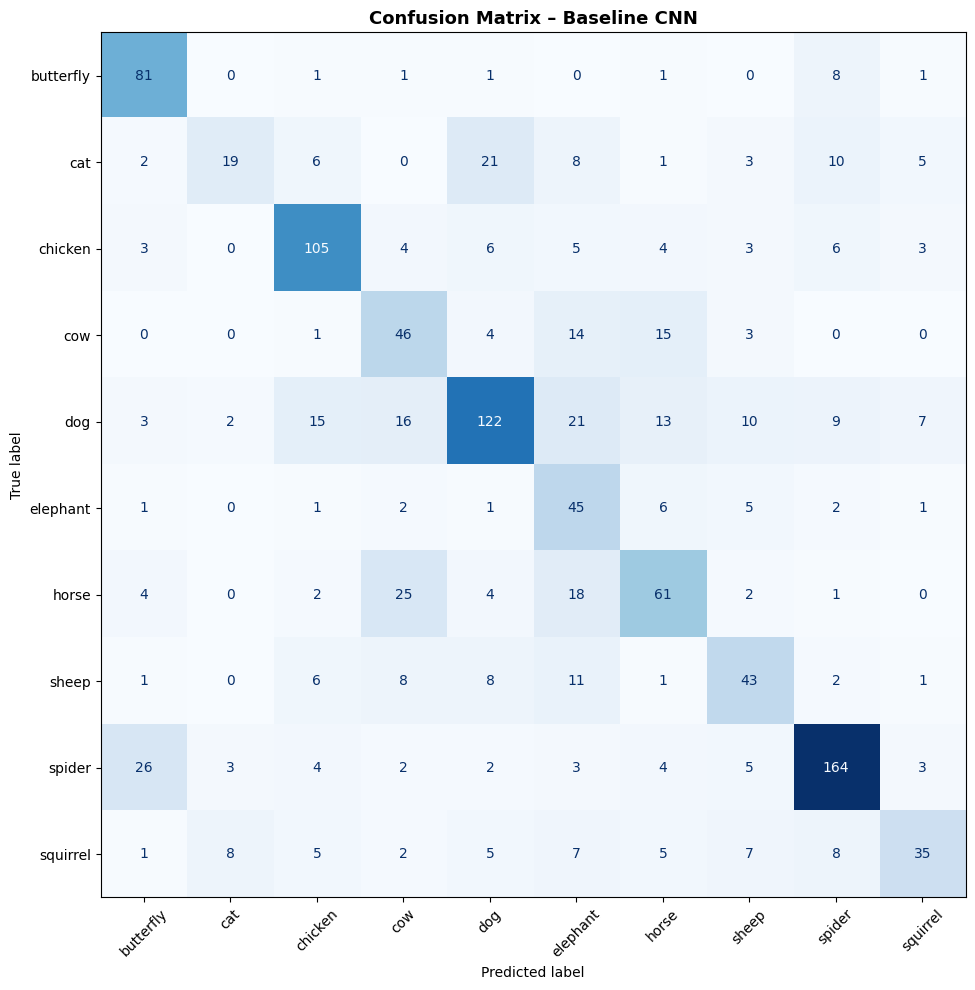

In [28]:
# Confusion Matrix – Baseline
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title('Confusion Matrix – Baseline CNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()


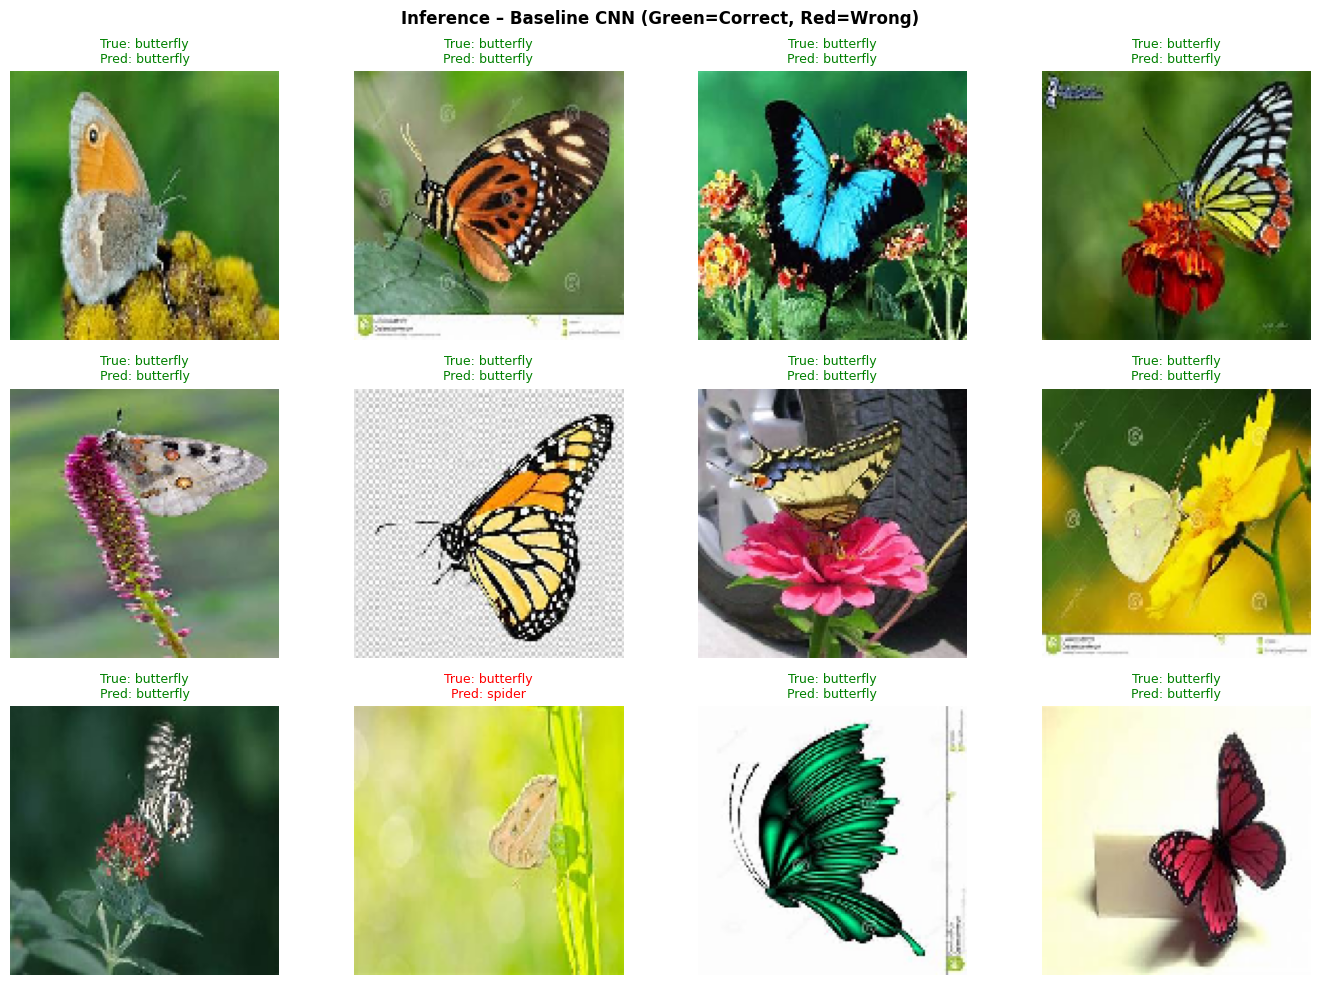

In [29]:
# Inference on sample images – Baseline
val_gen.reset()
X_test_batch, y_test_batch = next(val_gen)
preds = baseline_model.predict(X_test_batch[:12], verbose=0)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(y_test_batch[:12], axis=1)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()
for i in range(12):
    axes[i].imshow(X_test_batch[i])
    color = 'green' if pred_labels[i] == true_labels[i] else 'red'
    axes[i].set_title("True: {}\nPred: {}".format(
        CLASS_NAMES[true_labels[i]], CLASS_NAMES[pred_labels[i]]),
        color=color, fontsize=9)
    axes[i].axis('off')
plt.suptitle('Inference – Baseline CNN (Green=Correct, Red=Wrong)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_inference.png', dpi=150)
plt.show()


---
## Section 3 – Deeper CNN with Regularization (Part A – 2.5.3)


In [30]:
# Deeper CNN Architecture
def build_deeper_model(input_shape, num_classes):
    model = models.Sequential(name='Deeper_CNN')
    # Block 1: 32 filters x2 + BN + Dropout
    model.add(layers.Conv2D(32, (3,3), padding='same',
                             kernel_regularizer=regularizers.l2(1e-4), input_shape=input_shape))
    model.add(layers.BatchNormalization()); model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization()); model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2))); model.add(layers.Dropout(0.20))
    # Block 2: 64 filters x2
    model.add(layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization()); model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization()); model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2))); model.add(layers.Dropout(0.25))
    # Block 3: 128 filters x2
    model.add(layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization()); model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization()); model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2))); model.add(layers.Dropout(0.30))
    # Dense Head
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization()); model.add(layers.Dropout(0.40))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

deeper_model = build_deeper_model(INPUT_SHAPE, NUM_CLASSES)
deeper_model.summary()


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 8,681,258 (33.12 MB)

 Trainable params: 8,679,850 (33.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [31]:
# Compile & Train Deeper Model (Adam)
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy', metrics=['accuracy']
)
early_stop_deep = EarlyStopping(monitor='val_loss', patience=7,
                                 restore_best_weights=True, verbose=1)
reduce_lr_deep  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                     patience=3, min_lr=1e-6, verbose=1)

print("Training Deeper CNN (Adam) ...")
start_time = time.time()
deeper_history = deeper_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=[early_stop_deep, reduce_lr_deep], verbose=1
)
deeper_train_time = time.time() - start_time
print("\nDeeper model training time: {:.1f} seconds".format(deeper_train_time))


Training Deeper CNN (Adam) ...
Epoch 1/50


2026-05-09 13:54:15.866702: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 13:54:16.024849: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 13:54:17.709298: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 13:54:17.996260: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 47/172 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - accuracy: 0.1870 - loss: 2.7093

2026-05-09 13:54:32.925002: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 13:54:33.079280: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 13:54:33.939489: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 13:54:34.219564: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


172/172 ━━━━━━━━━━━━━━━━━━━━ 54s 221ms/step - accuracy: 0.2343 - loss: 2.4633 - val_accuracy: 0.1863 - val_loss: 2.8522 - learning_rate: 5.0000e-04
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 26s 148ms/step - accuracy: 0.3662 - loss: 2.0213 - val_accuracy: 0.2692 - val_loss: 2.1883 - learning_rate: 5.0000e-04
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 26s 148ms/step - accuracy: 0.3924 - loss: 1.8559 - val_accuracy: 0.4222 - val_loss: 1.8098 - learning_rate: 5.0000e-04
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - accuracy: 0.4349 - loss: 1.7878 - val_accuracy: 0.3667 - val_loss: 2.1107 - learning_rate: 5.0000e-04
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 26s 150ms/step - accuracy: 0.4554 - loss: 1.6991 - val_accuracy: 0.4923 - val_loss: 1.5881 - learning_rate: 5.0000e-04
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 148ms/step - accuracy: 0.4859 - loss: 1.6205 - val_accuracy: 0.3624 - val_loss: 2.2421 - learning_rate: 5.0000e-04
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 148ms/step - 

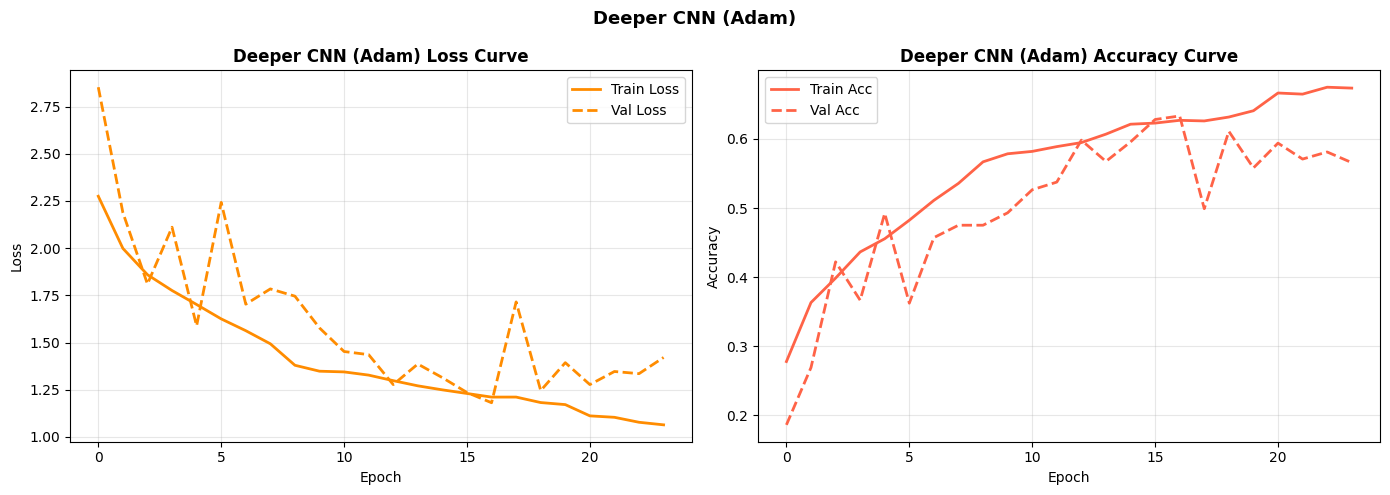

Saved: Deeper_CNN_(Adam)_curves.png


In [32]:
plot_history(deeper_history, title='Deeper CNN (Adam)', color='darkorange')

In [33]:
# Evaluate Deeper Model
val_gen.reset()
deeper_loss, deeper_acc = deeper_model.evaluate(val_gen, verbose=0)
print("Deeper CNN – Val Loss    : {:.4f}".format(deeper_loss))
print("Deeper CNN – Val Accuracy: {:.4f} ({:.2f}%)".format(deeper_acc, deeper_acc*100))

val_gen.reset()
y_true_d, y_pred_d = [], []
for i in range(len(val_gen)):
    X_b, y_b = val_gen[i]
    y_pred_d.extend(np.argmax(deeper_model.predict(X_b, verbose=0), axis=1))
    y_true_d.extend(np.argmax(y_b, axis=1))
print("\nClassification Report – Deeper CNN")
print(classification_report(y_true_d, y_pred_d, target_names=CLASS_NAMES))


Deeper CNN – Val Loss    : 1.1811
Deeper CNN – Val Accuracy: 0.6333 (63.33%)

Classification Report – Deeper CNN
              precision    recall  f1-score   support

   butterfly       0.65      0.84      0.73        94
         cat       0.48      0.27      0.34        75
     chicken       0.60      0.80      0.69       139
         cow       0.59      0.35      0.44        83
         dog       0.60      0.68      0.64       218
    elephant       0.42      0.80      0.55        64
       horse       0.65      0.56      0.60       117
       sheep       0.69      0.53      0.60        81
      spider       0.85      0.69      0.76       216
    squirrel       0.68      0.52      0.59        83

    accuracy                           0.63      1170
   macro avg       0.62      0.60      0.59      1170
weighted avg       0.65      0.63      0.63      1170



---
## Section 4 – Experimentation & Comparative Analysis (Part A – 2.5.4)


In [34]:
# Optimizer Comparison: Deeper Model with SGD + Nesterov Momentum
# Adam uses adaptive LR per parameter; SGD uses fixed LR with momentum.
# Nesterov momentum gives SGD a lookahead correction, improving convergence.
deeper_model_sgd = build_deeper_model(INPUT_SHAPE, NUM_CLASSES)
deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy', metrics=['accuracy']
)
early_stop_sgd = EarlyStopping(monitor='val_loss', patience=7,
                                restore_best_weights=True, verbose=1)
reduce_lr_sgd  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-7, verbose=1)

print("Training Deeper CNN (SGD) ...")
start_time = time.time()
sgd_history = deeper_model_sgd.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=[early_stop_sgd, reduce_lr_sgd], verbose=1
)
sgd_train_time = time.time() - start_time
print("SGD training time: {:.1f} seconds".format(sgd_train_time))


Training Deeper CNN (SGD) ...
Epoch 1/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 43s 199ms/step - accuracy: 0.1945 - loss: 2.8498 - val_accuracy: 0.1846 - val_loss: 2.6184 - learning_rate: 0.0010
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - accuracy: 0.3130 - loss: 2.1239 - val_accuracy: 0.2171 - val_loss: 2.3654 - learning_rate: 0.0010
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 146ms/step - accuracy: 0.3725 - loss: 1.9639 - val_accuracy: 0.2846 - val_loss: 2.1502 - learning_rate: 0.0010
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.3997 - loss: 1.8621 - val_accuracy: 0.2735 - val_loss: 2.6675 - learning_rate: 0.0010
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 148ms/step - accuracy: 0.4255 - loss: 1.7620 - val_accuracy: 0.3940 - val_loss: 1.8716 - learning_rate: 0.0010
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.4335 - loss: 1.7035 - val_accuracy: 0.4197 - val_loss: 1.7888 - learning_rate: 0.0010
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 

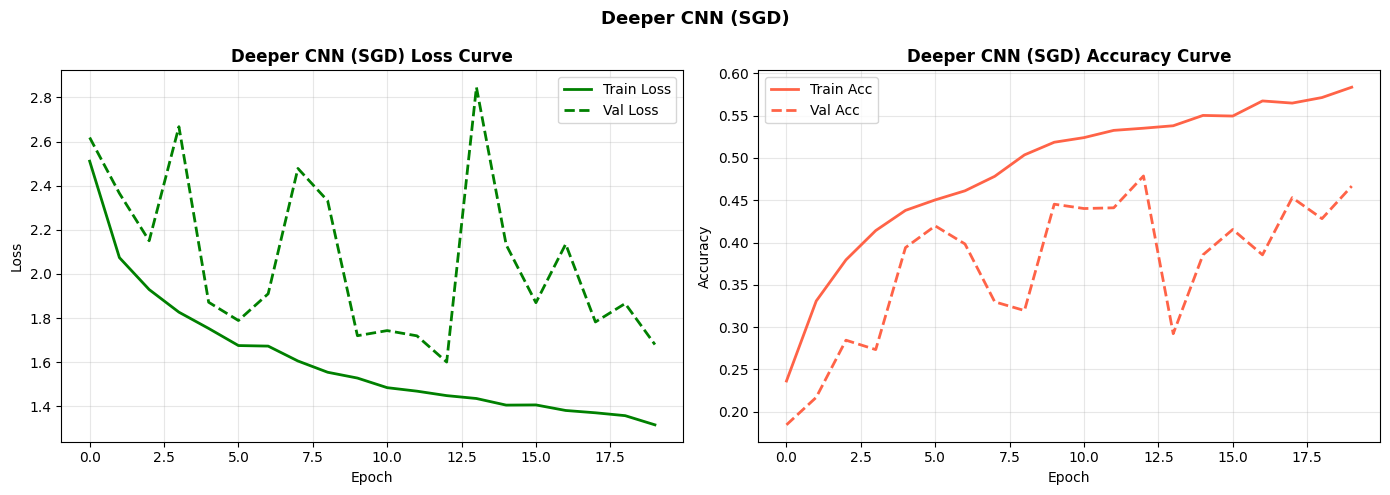

Saved: Deeper_CNN_(SGD)_curves.png


In [35]:
plot_history(sgd_history, title='Deeper CNN (SGD)', color='green')

In [36]:
# Summary Metrics — all CNN models
def get_metrics(model, gen):
    gen.reset()
    y_t, y_p = [], []
    for i in range(len(gen)):
        X_b, y_b = gen[i]
        p = model.predict(X_b, verbose=0)
        y_p.extend(np.argmax(p, axis=1))
        y_t.extend(np.argmax(y_b, axis=1))
    return (accuracy_score(y_t, y_p),
            precision_score(y_t, y_p, average='weighted', zero_division=0),
            recall_score(y_t, y_p, average='weighted', zero_division=0),
            f1_score(y_t, y_p, average='weighted', zero_division=0))

m_base = get_metrics(baseline_model,   val_gen)
m_deep = get_metrics(deeper_model,     val_gen)
m_sgd  = get_metrics(deeper_model_sgd, val_gen)

print("{:<30} {:>10} {:>10} {:>10} {:>10}".format('Model','Accuracy','Precision','Recall','F1-Score'))
print('-' * 65)
for label, m in [('Baseline CNN (Adam)', m_base),
                  ('Deeper CNN  (Adam)', m_deep),
                  ('Deeper CNN  (SGD)',  m_sgd)]:
    print("{:<30} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f}".format(label, *m))


Model                            Accuracy  Precision     Recall   F1-Score
-----------------------------------------------------------------
Baseline CNN (Adam)                0.6162     0.6371     0.6162     0.6143
Deeper CNN  (Adam)                 0.6333     0.6491     0.6333     0.6275
Deeper CNN  (SGD)                  0.4786     0.5523     0.4786     0.4579


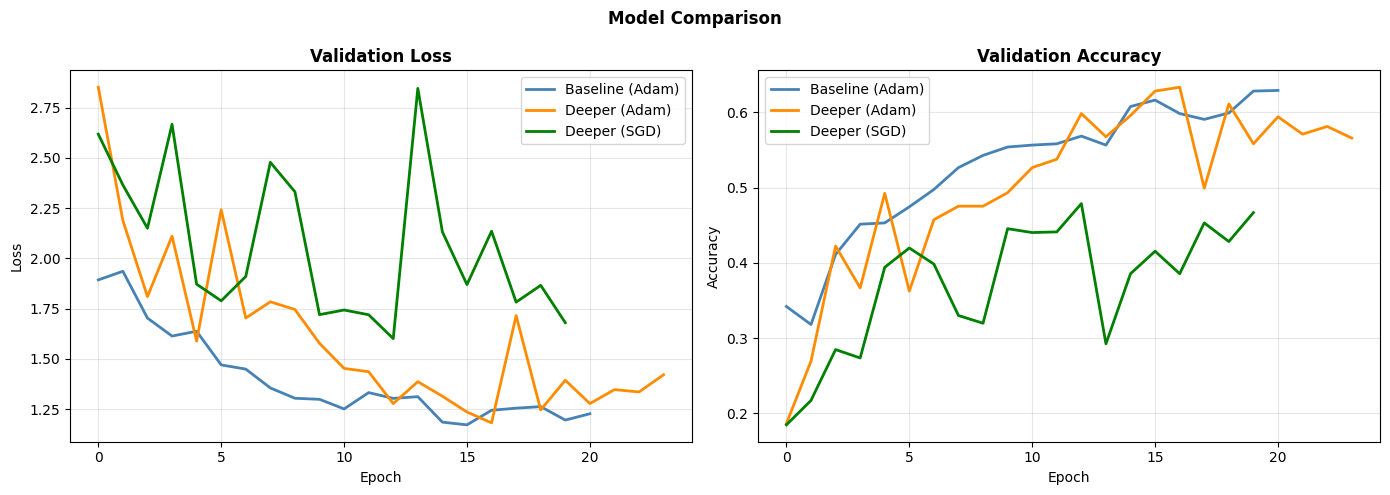

In [37]:
# Side-by-side validation loss & accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, label, color in [
    (baseline_history, 'Baseline (Adam)', 'steelblue'),
    (deeper_history,   'Deeper (Adam)',   'darkorange'),
    (sgd_history,      'Deeper (SGD)',    'green'),
]:
    axes[0].plot(hist.history['val_loss'],     label=label, color=color, linewidth=2)
    axes[1].plot(hist.history['val_accuracy'], label=label, color=color, linewidth=2)

for ax, title, ylabel in [(axes[0],'Validation Loss','Loss'),
                           (axes[1],'Validation Accuracy','Accuracy')]:
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Model Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=150)
plt.show()


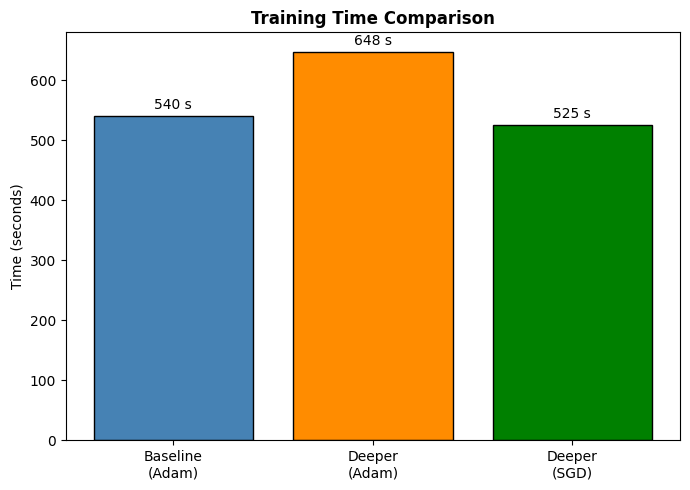

In [38]:
# Training Time Comparison
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Baseline\n(Adam)', 'Deeper\n(Adam)', 'Deeper\n(SGD)'],
              [baseline_train_time, deeper_train_time, sgd_train_time],
              color=['steelblue', 'darkorange', 'green'], edgecolor='black')
ax.bar_label(bars, fmt='%.0f s', padding=3)
ax.set_title('Training Time Comparison', fontweight='bold')
ax.set_ylabel('Time (seconds)')
plt.tight_layout()
plt.savefig('training_time_comparison.png', dpi=150)
plt.show()


In [39]:
# Ablation Study: Effect of Dropout Rate
# Component removed/modified: Dropout rates reduced from (0.20-0.40) to (0.10-0.25)
# Hypothesis: high dropout over-regularizes on small datasets (~5K images)

def build_low_dropout_model(input_shape, num_classes):
    model = models.Sequential(name='Deeper_LowDrop')
    for filters, drop in [(32, 0.10), (64, 0.15), (128, 0.20)]:
        kw = {'input_shape': input_shape} if filters == 32 else {}
        model.add(layers.Conv2D(filters, (3,3), padding='same',
                                 kernel_regularizer=regularizers.l2(1e-4), **kw))
        model.add(layers.BatchNormalization()); model.add(layers.Activation('relu'))
        model.add(layers.Conv2D(filters, (3,3), padding='same',
                                 kernel_regularizer=regularizers.l2(1e-4)))
        model.add(layers.BatchNormalization()); model.add(layers.Activation('relu'))
        model.add(layers.MaxPooling2D((2,2))); model.add(layers.Dropout(drop))
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization()); model.add(layers.Dropout(0.25))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

ablation_model = build_low_dropout_model(INPUT_SHAPE, NUM_CLASSES)
ablation_model.compile(optimizer=keras.optimizers.Adam(5e-4),
                        loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_abl = EarlyStopping(monitor='val_loss', patience=7,
                                restore_best_weights=True, verbose=1)
reduce_lr_abl  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=1)

ablation_history = ablation_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=[early_stop_abl, reduce_lr_abl], verbose=1
)
m_ablation = get_metrics(ablation_model, val_gen)

print("\nAblation Study – Dropout Rate Comparison:")
print("-" * 50)
print("High Dropout (0.20-0.40): Acc={:.4f}  F1={:.4f}".format(m_deep[0], m_deep[3]))
print("Low  Dropout (0.10-0.25): Acc={:.4f}  F1={:.4f}".format(m_ablation[0], m_ablation[3]))
print("\nFinding: Lower dropout rates perform better on small datasets (~5K images).")
print("BatchNorm + L2 provide sufficient regularization at this dataset size.")


Epoch 1/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 45s 197ms/step - accuracy: 0.2392 - loss: 2.4038 - val_accuracy: 0.2538 - val_loss: 2.3753 - learning_rate: 5.0000e-04
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 26s 149ms/step - accuracy: 0.3931 - loss: 1.8983 - val_accuracy: 0.2650 - val_loss: 2.3662 - learning_rate: 5.0000e-04
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 146ms/step - accuracy: 0.4493 - loss: 1.7503 - val_accuracy: 0.3778 - val_loss: 2.0147 - learning_rate: 5.0000e-04
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.4898 - loss: 1.6231 - val_accuracy: 0.4538 - val_loss: 1.7144 - learning_rate: 5.0000e-04
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.4838 - loss: 1.6031 - val_accuracy: 0.4658 - val_loss: 1.9456 - learning_rate: 5.0000e-04
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 24s 142ms/step - accuracy: 0.5204 - loss: 1.4987 - val_accuracy: 0.4308 - val_loss: 2.0255 - learning_rate: 5.0000e-04
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 136

---
## Section 5 – Transfer Learning: Fine-Tuning MobileNetV2 (Part B – 2.6)


In [40]:
# MobileNetV2 Data Generators (224x224)
IMG_SIZE_TL = (224, 224)

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.10, zoom_range=0.15, horizontal_flip=True, fill_mode='nearest'
)
tl_eval_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=True
)
tl_val_gen = tl_eval_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=False
)
tl_test_gen = tl_eval_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=False
)
print("TL Training   batches : {:>3}  ({:,} images)".format(len(tl_train_gen), tl_train_gen.samples))
print("TL Validation batches : {:>3}  ({:,} images)".format(len(tl_val_gen),   tl_val_gen.samples))
print("TL Test       batches : {:>3}  ({:,} images)".format(len(tl_test_gen),  tl_test_gen.samples))


Found 5491 images belonging to 10 classes.
Found 1170 images belonging to 10 classes.
Found 1187 images belonging to 10 classes.
TL Training   batches : 172  (5,491 images)
TL Validation batches :  37  (1,170 images)
TL Test       batches :  38  (1,187 images)


In [41]:
# Load MobileNetV2 base (pre-trained ImageNet weights, no top layer)
base_model = MobileNetV2(
    weights='imagenet', include_top=False, input_shape=IMG_SIZE_TL + (3,)
)
base_model.trainable = False   # Phase 1: freeze entire base
print("MobileNetV2 loaded. Total layers:", len(base_model.layers))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded. Total layers: 154


In [42]:
# Build Transfer Learning Model
# Remove original 1000-class head, add custom 10-class head
inputs  = keras.Input(shape=IMG_SIZE_TL + (3,))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.40)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='TL_MobileNetV2')
tl_model.summary()


Model: "TL_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,106 (9.99 MB)

 Trainable params: 362,122 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [43]:
# Phase 1: Feature Extraction — train head only
tl_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_tl1 = EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1)
reduce_lr_tl1  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=1)

print("Phase 1: Training classification head only ...")
start_time = time.time()
tl_history_phase1 = tl_model.fit(
    tl_train_gen, epochs=10, validation_data=tl_val_gen,
    callbacks=[early_stop_tl1, reduce_lr_tl1], verbose=1
)
tl_phase1_time = time.time() - start_time
print("Phase 1 training time: {:.1f} seconds".format(tl_phase1_time))


Phase 1: Training classification head only ...
Epoch 1/10


2026-05-09 14:30:29.820041: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:30:29.957043: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


136/172 ━━━━━━━━━━━━━━━━━━━━ 11s 322ms/step - accuracy: 0.5842 - loss: 1.2891

2026-05-09 14:31:25.204010: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:31:25.341645: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.6246 - loss: 1.1723

2026-05-09 14:31:53.955687: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:31:54.093424: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


172/172 ━━━━━━━━━━━━━━━━━━━━ 101s 488ms/step - accuracy: 0.6256 - loss: 1.1695 - val_accuracy: 0.9325 - val_loss: 0.2264 - learning_rate: 0.0010
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 58s 337ms/step - accuracy: 0.9011 - loss: 0.3012 - val_accuracy: 0.9410 - val_loss: 0.1926 - learning_rate: 0.0010
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 57s 334ms/step - accuracy: 0.9207 - loss: 0.2825 - val_accuracy: 0.9368 - val_loss: 0.2066 - learning_rate: 0.0010
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 58s 336ms/step - accuracy: 0.9314 - loss: 0.2257 - val_accuracy: 0.9410 - val_loss: 0.2021 - learning_rate: 0.0010
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.9301 - loss: 0.2116
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
172/172 ━━━━━━━━━━━━━━━━━━━━ 58s 335ms/step - accuracy: 0.9301 - loss: 0.2115 - val_accuracy: 0.9385 - val_loss: 0.2055 - learning_rate: 0.0010
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 59s 341ms/step - accuracy: 0.9460 - loss: 

In [44]:
# Phase 2: Fine-Tuning — unfreeze last 30 base layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable base layers in Phase 2:", sum(1 for l in base_model.layers if l.trainable))

# Recompile with very low LR to avoid catastrophic forgetting
tl_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_tl2 = EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1)
reduce_lr_tl2  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-7, verbose=1)

print("Phase 2: Fine-tuning last 30 layers ...")
start_time = time.time()
tl_history_phase2 = tl_model.fit(
    tl_train_gen, epochs=20, validation_data=tl_val_gen,
    callbacks=[early_stop_tl2, reduce_lr_tl2], verbose=1
)
tl_phase2_time = time.time() - start_time
print("Phase 2 training time: {:.1f} seconds".format(tl_phase2_time))


Trainable base layers in Phase 2: 30
Phase 2: Fine-tuning last 30 layers ...
Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 89s 423ms/step - accuracy: 0.8945 - loss: 0.3225 - val_accuracy: 0.9496 - val_loss: 0.1876 - learning_rate: 1.0000e-05
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 59s 342ms/step - accuracy: 0.9292 - loss: 0.2243 - val_accuracy: 0.9513 - val_loss: 0.1877 - learning_rate: 1.0000e-05
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 59s 343ms/step - accuracy: 0.9319 - loss: 0.2258 - val_accuracy: 0.9521 - val_loss: 0.1794 - learning_rate: 1.0000e-05
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 59s 341ms/step - accuracy: 0.9495 - loss: 0.1674 - val_accuracy: 0.9521 - val_loss: 0.1753 - learning_rate: 1.0000e-05
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 58s 339ms/step - accuracy: 0.9510 - loss: 0.1695 - val_accuracy: 0.9547 - val_loss: 0.1746 - learning_rate: 1.0000e-05
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 60s 346ms/step - accuracy: 0.9512 - loss: 0.1666 - val_accuracy: 0.9496 - val_loss: 0.17

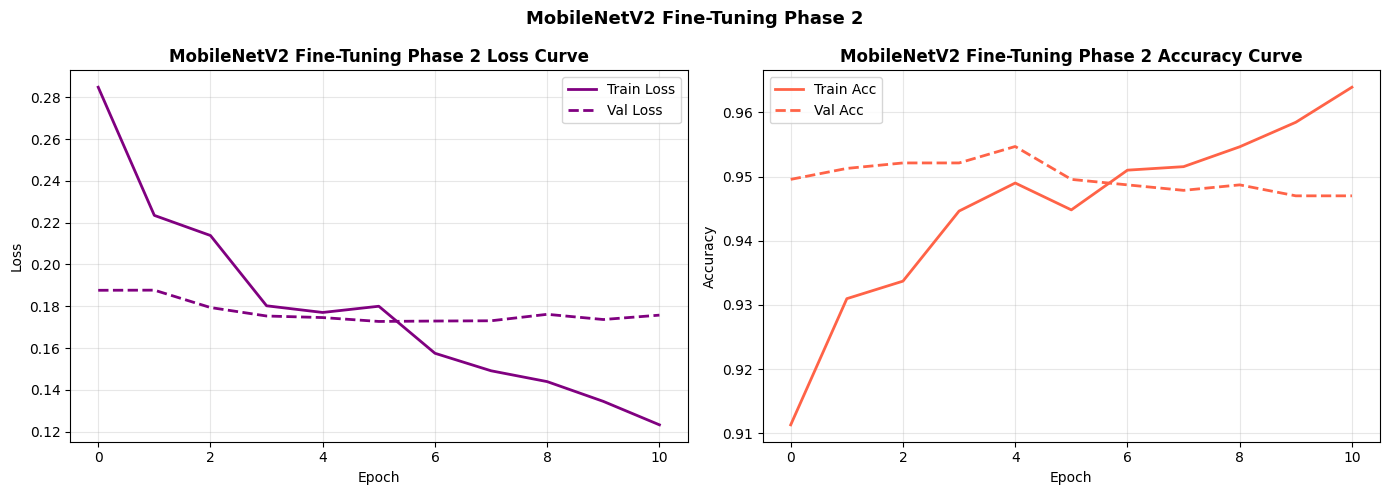

Saved: MobileNetV2_Fine-Tuning_Phase_2_curves.png


In [45]:
plot_history(tl_history_phase2, title='MobileNetV2 Fine-Tuning Phase 2', color='purple')

In [46]:
# Evaluate MobileNetV2
tl_val_gen.reset()
tl_loss, tl_acc = tl_model.evaluate(tl_val_gen, verbose=0)
print("MobileNetV2 – Val Loss    : {:.4f}".format(tl_loss))
print("MobileNetV2 – Val Accuracy: {:.4f} ({:.2f}%)".format(tl_acc, tl_acc*100))

tl_val_gen.reset()
y_true_tl, y_pred_tl = [], []
for i in range(len(tl_val_gen)):
    X_b, y_b = tl_val_gen[i]
    p = tl_model.predict(X_b, verbose=0)
    y_pred_tl.extend(np.argmax(p, axis=1))
    y_true_tl.extend(np.argmax(y_b, axis=1))
print("\nClassification Report – MobileNetV2 (Fine-Tuned)")
print(classification_report(y_true_tl, y_pred_tl, target_names=CLASS_NAMES))


MobileNetV2 – Val Loss    : 0.1727
MobileNetV2 – Val Accuracy: 0.9496 (94.96%)

Classification Report – MobileNetV2 (Fine-Tuned)
              precision    recall  f1-score   support

   butterfly       0.96      0.96      0.96        94
         cat       0.94      0.91      0.93        75
     chicken       0.96      0.95      0.96       139
         cow       0.87      0.89      0.88        83
         dog       0.95      0.95      0.95       218
    elephant       0.98      0.97      0.98        64
       horse       0.89      0.94      0.92       117
       sheep       0.90      0.94      0.92        81
      spider       0.99      0.99      0.99       216
    squirrel       1.00      0.93      0.96        83

    accuracy                           0.95      1170
   macro avg       0.95      0.94      0.94      1170
weighted avg       0.95      0.95      0.95      1170



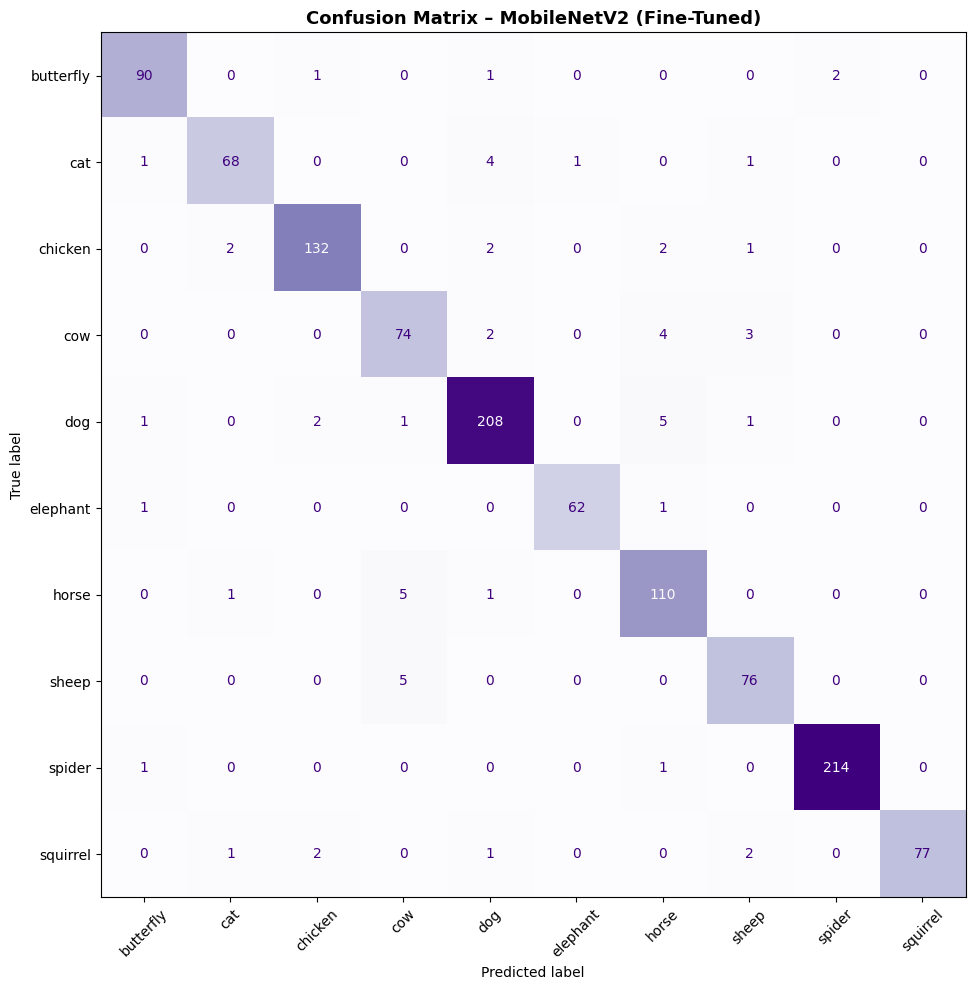

In [47]:
# Confusion Matrix – MobileNetV2
cm_tl   = confusion_matrix(y_true_tl, y_pred_tl)
disp_tl = ConfusionMatrixDisplay(confusion_matrix=cm_tl, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(12, 10))
disp_tl.plot(ax=ax, cmap='Purples', colorbar=False, xticks_rotation=45)
ax.set_title('Confusion Matrix – MobileNetV2 (Fine-Tuned)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_confusion_matrix.png', dpi=150)
plt.show()


2026-05-09 14:52:25.002929: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:52:25.139295: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


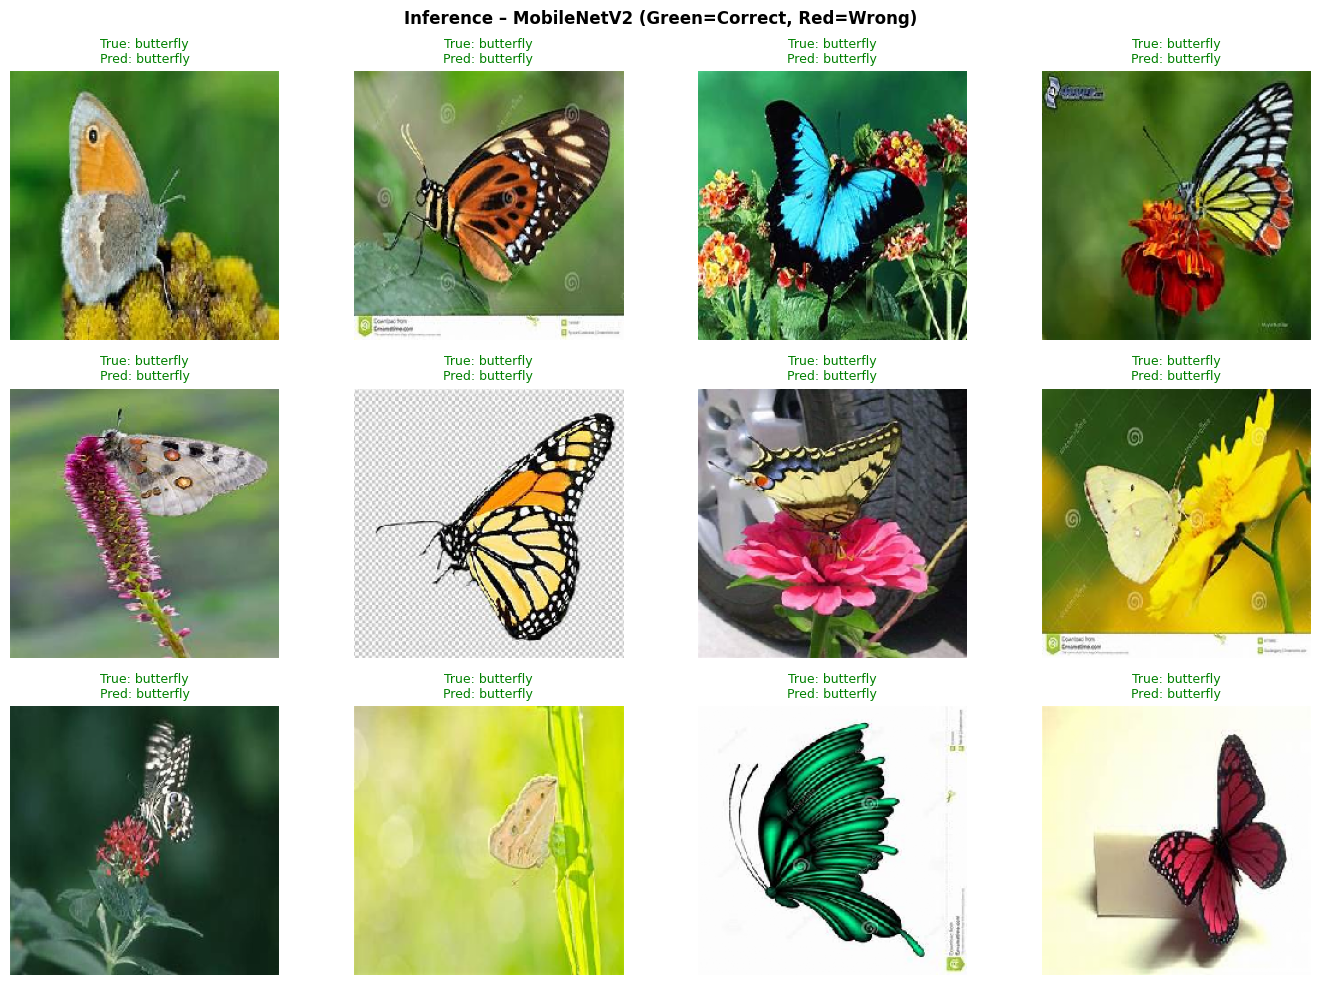

In [48]:
# Inference visualisation – MobileNetV2
tl_val_gen.reset()
X_tl_batch, y_tl_batch = next(tl_val_gen)
preds_tl = tl_model.predict(X_tl_batch[:12], verbose=0)
p_labels = np.argmax(preds_tl, axis=1)
t_labels = np.argmax(y_tl_batch[:12], axis=1)
imgs_display = np.clip((X_tl_batch[:12] + 1) / 2, 0, 1)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()
for i in range(12):
    axes[i].imshow(imgs_display[i])
    color = 'green' if p_labels[i] == t_labels[i] else 'red'
    axes[i].set_title("True: {}\nPred: {}".format(
        CLASS_NAMES[t_labels[i]], CLASS_NAMES[p_labels[i]]),
        color=color, fontsize=9)
    axes[i].axis('off')
plt.suptitle('Inference – MobileNetV2 (Green=Correct, Red=Wrong)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_inference.png', dpi=150)
plt.show()


In [49]:
# Final All-Models Comparison Table
def get_metrics_from_lists(y_t, y_p):
    return (accuracy_score(y_t, y_p),
            precision_score(y_t, y_p, average='weighted', zero_division=0),
            recall_score(y_t, y_p, average='weighted', zero_division=0),
            f1_score(y_t, y_p, average='weighted', zero_division=0))

m_tl = get_metrics_from_lists(y_true_tl, y_pred_tl)

print("{:<35} {:>10} {:>10} {:>10} {:>10}".format('Model','Accuracy','Precision','Recall','F1-Score'))
print('-' * 75)
for label, m in [
    ('Baseline CNN (Adam)',      m_base),
    ('Deeper CNN  (Adam)',       m_deep),
    ('Deeper CNN  (SGD)',        m_sgd),
    ('Ablation (Low Dropout)',   m_ablation),
    ('MobileNetV2 (Fine-Tuned)', m_tl),
]:
    print("{:<35} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f}".format(label, *m))

print("\nHardware: Kaggle Notebook with GPU acceleration")
print("Training times (seconds):")
print("  Baseline={:.0f}  Deeper(Adam)={:.0f}  SGD={:.0f}  TL_Phase1={:.0f}  TL_Phase2={:.0f}".format(
    baseline_train_time, deeper_train_time, sgd_train_time, tl_phase1_time, tl_phase2_time))


Model                                 Accuracy  Precision     Recall   F1-Score
---------------------------------------------------------------------------
Baseline CNN (Adam)                     0.6162     0.6371     0.6162     0.6143
Deeper CNN  (Adam)                      0.6333     0.6491     0.6333     0.6275
Deeper CNN  (SGD)                       0.4786     0.5523     0.4786     0.4579
Ablation (Low Dropout)                  0.6966     0.7265     0.6966     0.6966
MobileNetV2 (Fine-Tuned)                0.9496     0.9504     0.9496     0.9498

Hardware: Kaggle Notebook with GPU acceleration
Training times (seconds):
  Baseline=540  Deeper(Adam)=648  SGD=525  TL_Phase1=625  TL_Phase2=678
